# Heart Disease Prediction


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
files.upload()

Saving heart.csv.csv to heart.csv.csv


{'heart.csv.csv': b'age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num\r\n63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,fixed defect,0\r\n67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,normal,2\r\n67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,reversable defect,1\r\n37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,normal,0\r\n41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,normal,0\r\n56,Male,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,normal,0\r\n62,Female,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,normal,3\r\n57,Female,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,normal,0\r\n63,Male,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,reversable defect,2\r\n53,Male,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,down

In [4]:
df = pd.read_csv("heart.csv.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,normal,0


In [5]:
df.info() #Permet de voir les types de données et détecter les valeurs manquantes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   cp        920 non-null    object 
 3   trestbps  920 non-null    float64
 4   chol      920 non-null    float64
 5   fbs       920 non-null    bool   
 6   restecg   920 non-null    object 
 7   thalch    920 non-null    float64
 8   exang     920 non-null    bool   
 9   oldpeak   920 non-null    float64
 10  slope     920 non-null    object 
 11  thal      920 non-null    object 
 12  num       920 non-null    int64  
dtypes: bool(2), float64(4), int64(2), object(5)
memory usage: 81.0+ KB


In [6]:
df.describe() #Analyse des moyennes, min, max..

,age,trestbps,chol,thalch,oldpeak,num
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,131.995652,199.908696,137.692391,0.853261,0.995652
std,9.424685,18.451300,109.040171,25.145235,1.058049,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,177.750000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,1.000000
75%,60.000000,140.000000,267.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [7]:
df.isnull().sum() #Vérification des valeurs manquantes

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


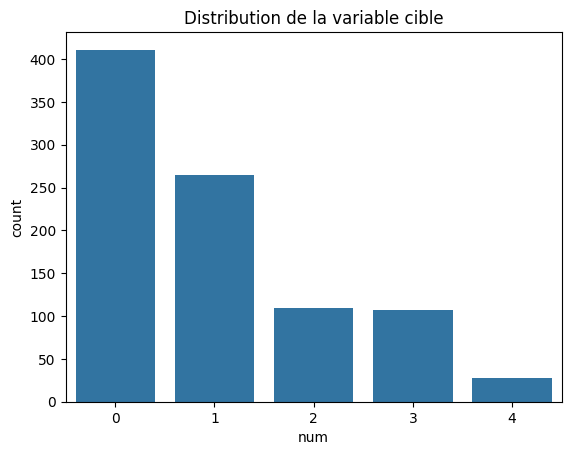

In [8]:
sns.countplot(x='num', data=df)
plt.title("Distribution de la variable cible")
plt.show()

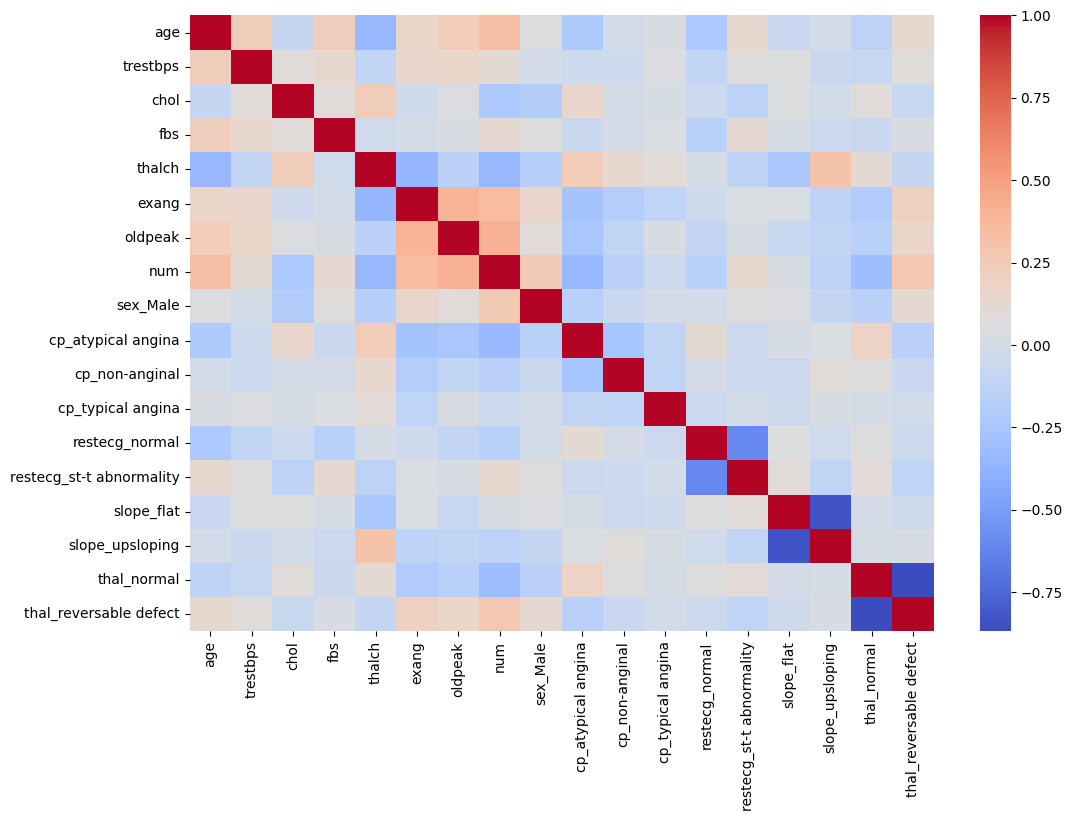

In [9]:
# convertir temporairement en numérique si besoin
df_temp = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(12,8))
sns.heatmap(df_temp.corr(), annot=False, cmap='coolwarm')
plt.show()
#Permet d’identifier les relations entre les variables

In [10]:
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0) #Transformation en classification binaire

In [11]:
df = pd.get_dummies(df, drop_first=True) #Conversion des variables texte en variables numériques

In [12]:
df['num'].value_counts() #Vérification du déséquilibre

,count
num,
1,509
0,411


In [13]:
X = df.drop('num', axis=1)
y = df['num']
#Séparation X / y

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)
#Mise à l’échelle des données pour améliorer les performances

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression()
model1.fit(X_train, y_train)

LogisticRegression()

In [17]:
from sklearn.neighbors import KNeighborsClassifier

model2 = KNeighborsClassifier()
model2.fit(X_train, y_train)

KNeighborsClassifier()

In [18]:
from sklearn.ensemble import RandomForestClassifier

model3 = RandomForestClassifier()
model3.fit(X_train, y_train)

RandomForestClassifier()

In [19]:
from sklearn.metrics import accuracy_score

pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)

print("Logistic:", accuracy_score(y_test, pred1))
print("KNN:", accuracy_score(y_test, pred2))
print("Random Forest:", accuracy_score(y_test, pred3))

Logistic: 0.8097826086956522
KNN: 0.8206521739130435
Random Forest: 0.875


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred3))

              precision    recall  f1-score   support

           0       0.84      0.85      0.85        75
           1       0.90      0.89      0.89       109

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



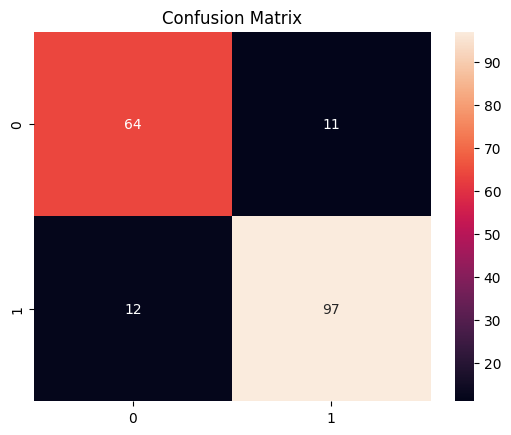

In [21]:
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test, pred3), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)

Best params: {'max_depth': None, 'n_estimators': 100}


In [23]:
import pickle

pickle.dump(model3, open("model.pkl", "wb"))

In [24]:
pickle.dump(X_train.shape[1], open("n_features.pkl", "wb"))